## [프로그램 5-1] YOLOv8 모델 불러오기

In [1]:
import torch

# YOLO 설치
!pip install ultralytics
from ultralytics import YOLO

# 장치 선택
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 사전 학습된 모델 로드
model = YOLO("yolov8s.pt").to(device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 10.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Using device: cuda


## [프로그램 5-2] 테스트 이미지 불러오기



In [6]:
from PIL import Image

img = Image.open("sample.jpg")     # RGB 이미지

# #COCO 이미지 예시를 사용
# from PIL import Image
# from io import BytesIO
# import requests

# url = "http://farm9.staticflickr.com/8261/8702818172_05105ccf66_z.jpg"

# resp = requests.get(url, timeout=10)
# resp.raise_for_status()  # HTTP 오류면 예외

# img = Image.open(BytesIO(resp.content)).convert("RGB")

## [프로그램 5-3] 모델 추론 실행하기


In [7]:
results = model.predict(img, device=device)





0: 448x640 11 persons, 2 bicycles, 2 cars, 1 bus, 1 train, 1 clock, 6.8ms
Speed: 7.3ms preprocess, 6.8ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)


In [12]:
model.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [16]:
print(results)

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'p

## [프로그램 5-4] 탐지 결과를 텍스트로 확인하기

In [8]:
for r in results:
    for box in r.boxes:           # boxes 경계 상자의 경로
        cls_id = int(box.cls)
        score = float(box.conf)
        x1, y1, x2, y2 = box.xyxy[0].tolist()   # 경계 상자 좌표
        print(f"class={model.names[cls_id]}, score={score:.3f}, box=({x1:.1f},{y1:.1f})-({x2:.1f},{y2:.1f})")



class=bicycle, score=0.809, box=(172.9,1013.4)-(362.1,1126.0)
class=bicycle, score=0.805, box=(749.2,1021.1)-(897.0,1144.0)
class=bus, score=0.693, box=(1524.7,914.2)-(1766.5,1019.9)
class=person, score=0.649, box=(1714.1,959.7)-(1749.6,1078.5)
class=train, score=0.600, box=(0.0,821.4)-(918.8,1025.3)
class=person, score=0.570, box=(218.1,911.7)-(336.0,1115.2)
class=person, score=0.551, box=(763.5,934.1)-(867.8,1118.5)
class=person, score=0.523, box=(1468.0,951.6)-(1505.9,1047.1)
class=car, score=0.512, box=(843.9,956.4)-(1024.2,1063.2)
class=person, score=0.489, box=(1179.6,953.0)-(1218.3,1066.9)
class=car, score=0.441, box=(751.2,956.9)-(1023.4,1064.5)
class=person, score=0.420, box=(997.6,948.6)-(1030.8,1044.6)
class=person, score=0.415, box=(434.9,988.0)-(506.3,1117.3)
class=person, score=0.409, box=(1162.6,952.5)-(1203.1,1067.2)
class=person, score=0.384, box=(1221.7,958.3)-(1263.0,1065.2)
class=person, score=0.321, box=(755.7,945.1)-(895.2,1096.5)
class=clock, score=0.298, box=(10

In [17]:
print(dir(results[0]))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_keys', 'boxes', 'cpu', 'cuda', 'depth', 'keypoints', 'masks', 'names', 'new', 'numpy', 'obb', 'orig_img', 'orig_shape', 'path', 'plot', 'probs', 'save', 'save_crop', 'save_dir', 'save_txt', 'semantic_mask', 'show', 'speed', 'summary', 'to', 'to_csv', 'to_df', 'to_json', 'update', 'verbose']


## [프로그램 5-5] 탐지 결과를 시각화하기


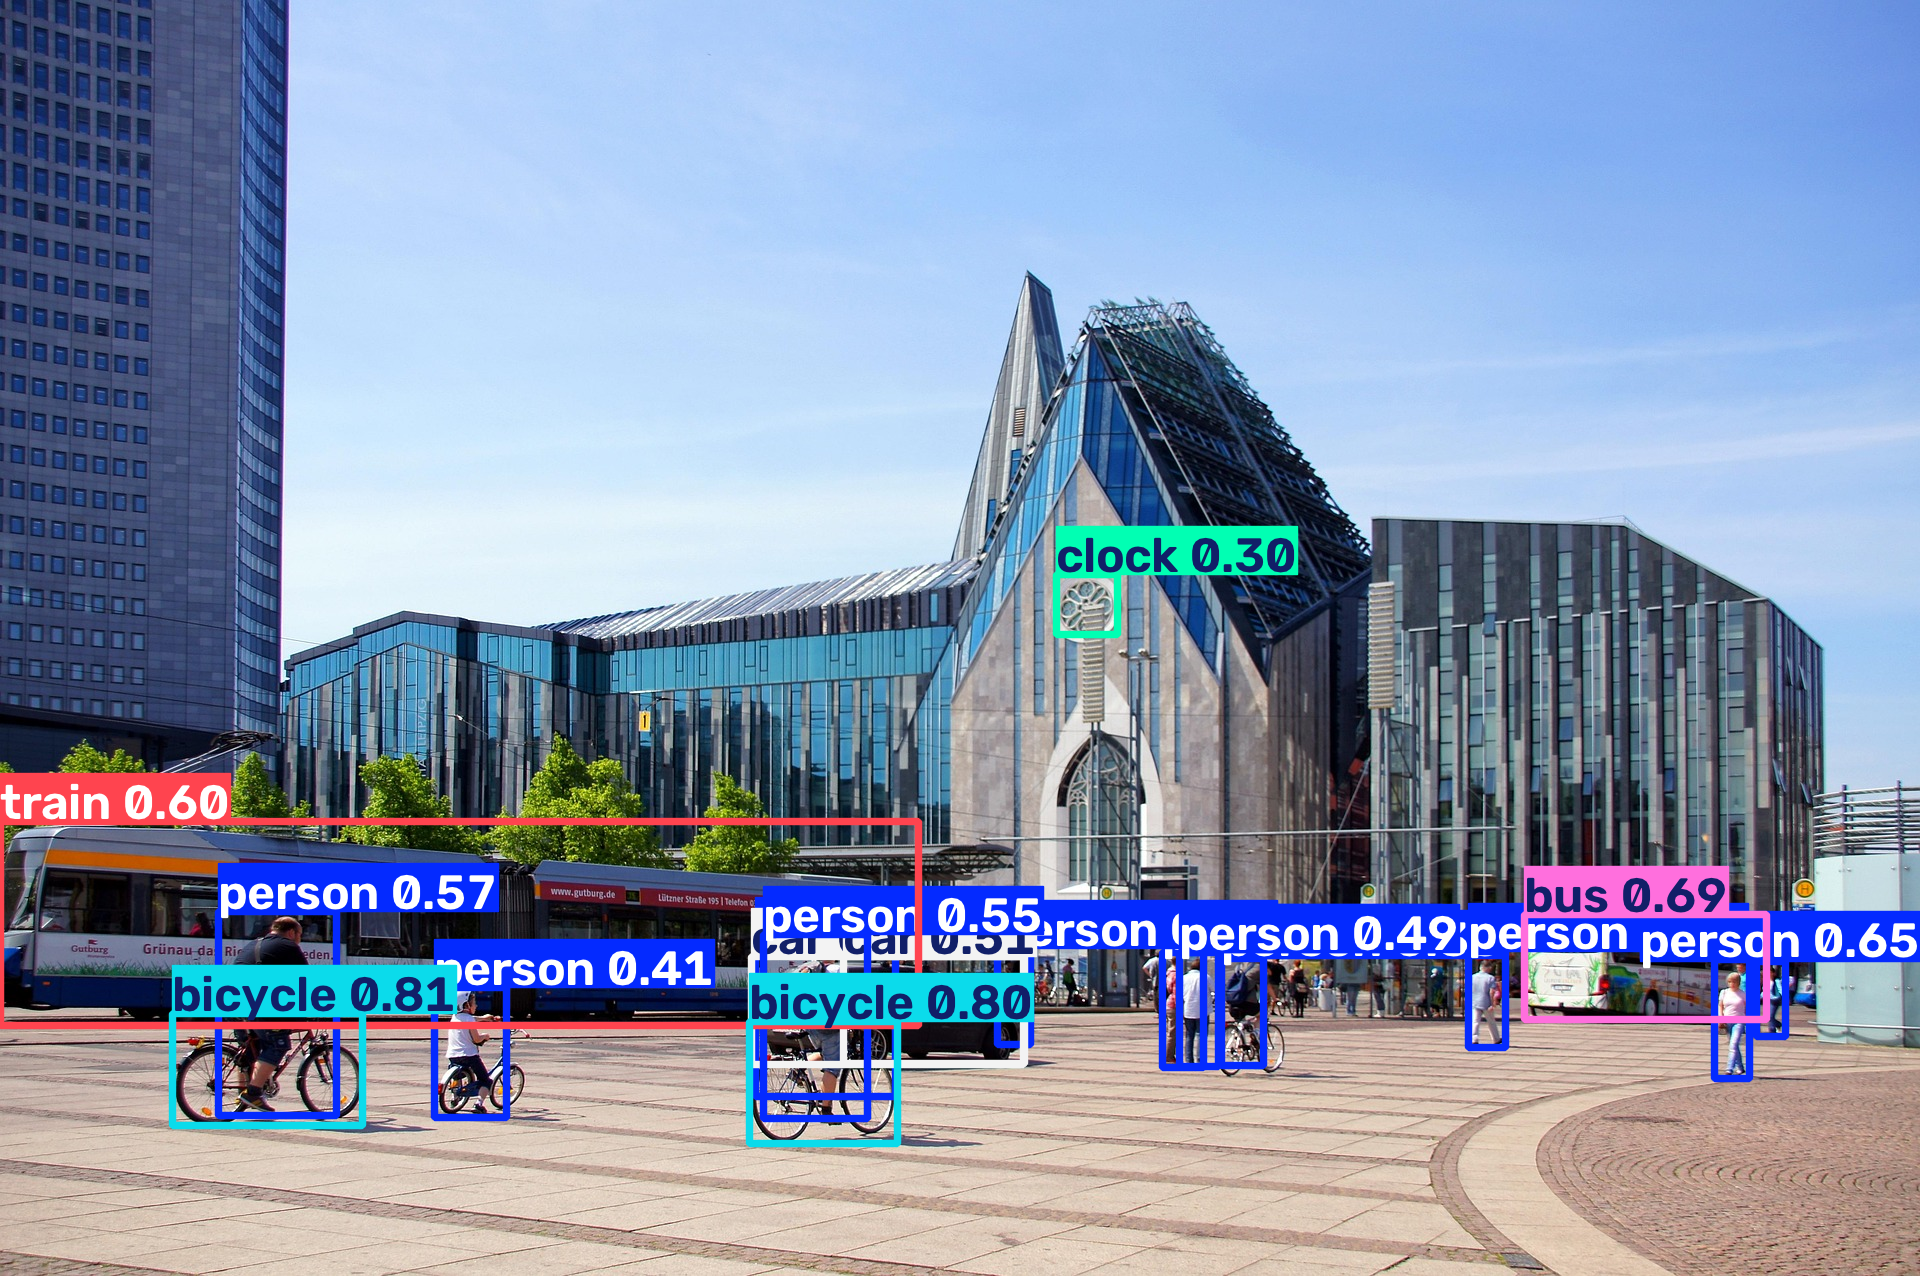

In [18]:
results[0].save("detected.jpg")      # 탐지 결과 이미지 저장
results[0].show()                    # 주피터/콜랩 환경에서 시각화

